In [7]:
!pip install huggingface_hub pandas -q

In [8]:
from huggingface_hub import hf_hub_download
import tarfile
import os
import pandas as pd

# 1. Descargar el .tar.gz directamente
tar_path = hf_hub_download(
    repo_id="cqchangm/flores200",
    filename="flores200_dataset.tar.gz",
    repo_type="dataset"
)

# 2. Descomprimir
extract_dir = "flores200_local"

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(extract_dir)

# 3. Ver archivos
for root, dirs, files in os.walk(extract_dir):
    print(root, files[:5])
    break

/tmp/ipykernel_3115/2371948997.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


flores200_local []


In [9]:
idiomas = {
    "eng_Latn": "English",
    "spa_Latn": "Español",
    "por_Latn": "Português",
    "deu_Latn": "Deutsch",
    "zho_Hans": "中文"
}

split = "dev"

filas = []

for codigo, nombre in idiomas.items():
    archivo = os.path.join(
        extract_dir,
        "flores200_dataset",
        split,
        f"{codigo}.{split}"
    )

    with open(archivo, "r", encoding="utf-8") as f:
        oraciones = [line.strip() for line in f.readlines()]

    for i, texto in enumerate(oraciones):
        filas.append({
            "ID": i,
            "Idioma": codigo,
            "Nombre_Idioma": nombre,
            "Texto": texto,
            "Split": split
        })

df_long = pd.DataFrame(filas)

df_wide = df_long.pivot(
    index="ID",
    columns="Idioma",
    values="Texto"
).reset_index()

df_long.to_csv("flores200_formato_largo.csv", index=False, encoding="utf-8-sig")
df_wide.to_csv("flores200_formato_ancho.csv", index=False, encoding="utf-8-sig")

print(df_long.head())
print(df_wide.head())

   ID    Idioma Nombre_Idioma  \
0   0  eng_Latn       English   
1   1  eng_Latn       English   
2   2  eng_Latn       English   
3   3  eng_Latn       English   
4   4  eng_Latn       English   

                                               Texto Split  
0  On Monday, scientists from the Stanford Univer...   dev  
1  Lead researchers say this may bring early dete...   dev  
2  The JAS 39C Gripen crashed onto a runway at ar...   dev  
3  The pilot was identified as Squadron Leader Di...   dev  
4  Local media reports an airport fire vehicle ro...   dev  
Idioma  ID                                           deu_Latn  \
0        0  Am Montag haben die Wisenschaftler der Stanfor...   
1        1  Führende Forscher sagen, dass dies die Früherk...   
2        2  Der JAS 39C Gripen stürzte gegen 9:30 Uhr Orts...   
3        3  Der Pilot wurde als Staffelführer Dilokrit Pat...   
4        4  Lokale Medien berichten, dass ein Feuerwehrwag...   

Idioma                                      

In [10]:
from google.colab import files

files.download("flores200_formato_largo.csv")
files.download("flores200_formato_ancho.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ============================================================
# 0. INSTALACIÓN DE LIBRERÍAS
# ============================================================

!pip install tiktoken pingouin scikit-posthocs statsmodels -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.0 MB/s eta 0:00:00


In [12]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np

import tiktoken

import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare, shapiro
from scipy.stats import wilcoxon

import pingouin as pg
import statsmodels.formula.api as smf

from itertools import combinations

In [13]:
# ============================================================
# 2. CARGA DE DATOS
# ============================================================

# En Colab, sube tu archivo flores200_formato_largo.csv
# o ajusta el nombre si aparece como flores200_formato_largo(1).csv

df = pd.read_csv("/content/flores200_formato_largo.csv")

df.head()

,ID,Idioma,Nombre_Idioma,Texto,Split
0,0,eng_Latn,English,"On Monday, scientists from the Stanford Univer...",dev
1,1,eng_Latn,English,Lead researchers say this may bring early dete...,dev
2,2,eng_Latn,English,The JAS 39C Gripen crashed onto a runway at ar...,dev
3,3,eng_Latn,English,The pilot was identified as Squadron Leader Di...,dev
4,4,eng_Latn,English,Local media reports an airport fire vehicle ro...,dev


In [14]:
# ============================================================
# 3. TOKENIZACIÓN DEL CORPUS
# ============================================================

# Tokenizador compatible con modelos GPT modernos
encoding = tiktoken.get_encoding("cl100k_base")

def contar_tokens(texto):
    if pd.isna(texto):
        return np.nan
    return len(encoding.encode(str(texto)))

df["Tokens"] = df["Texto"].apply(contar_tokens)

# Métricas adicionales
df["Caracteres"] = df["Texto"].astype(str).str.len()
df["Palabras"] = df["Texto"].astype(str).str.split().apply(len)

df["Tokens_por_palabra"] = df["Tokens"] / df["Palabras"]
df["Tokens_por_caracter"] = df["Tokens"] / df["Caracteres"]

df.head()

,ID,Idioma,Nombre_Idioma,Texto,Split,Tokens,Caracteres,Palabras,Tokens_por_palabra,Tokens_por_caracter
0,0,eng_Latn,English,"On Monday, scientists from the Stanford Univer...",dev,49,264,43,1.139535,0.185606
1,1,eng_Latn,English,Lead researchers say this may bring early dete...,dev,41,229,36,1.138889,0.179039
2,2,eng_Latn,English,The JAS 39C Gripen crashed onto a runway at ar...,dev,36,137,24,1.500000,0.262774
3,3,eng_Latn,English,The pilot was identified as Squadron Leader Di...,dev,14,62,9,1.555556,0.225806
4,4,eng_Latn,English,Local media reports an airport fire vehicle ro...,dev,12,73,11,1.090909,0.164384


In [15]:
# ============================================================
# 4. MATRIZ ID x IDIOMA
# ============================================================

tokens_wide = df.pivot(
    index="ID",
    columns="Idioma",
    values="Tokens"
).reset_index()

tokens_wide.head()

Idioma,ID,deu_Latn,eng_Latn,por_Latn,spa_Latn,zho_Hans
0,0,79,49,80,90,93
1,1,80,41,84,73,103
2,2,55,36,49,54,70
3,3,19,14,23,22,36
4,4,26,12,29,28,31


In [16]:
# ============================================================
# 5. ESTADÍSTICAS DESCRIPTIVAS POR IDIOMA
# ============================================================

resumen_idioma = df.groupby(["Idioma", "Nombre_Idioma"]).agg(
    Media_Tokens=("Tokens", "mean"),
    Mediana_Tokens=("Tokens", "median"),
    Desv_Tokens=("Tokens", "std"),
    Min_Tokens=("Tokens", "min"),
    Max_Tokens=("Tokens", "max"),
    Media_Tokens_Palabra=("Tokens_por_palabra", "mean"),
    Media_Tokens_Caracter=("Tokens_por_caracter", "mean"),
    N=("Tokens", "count")
).reset_index()

resumen_idioma

,Idioma,Nombre_Idioma,Media_Tokens,Mediana_Tokens,Desv_Tokens,Min_Tokens,Max_Tokens,Media_Tokens_Palabra,Media_Tokens_Caracter,N
0,deu_Latn,Deutsch,40.738215,39.0,14.069701,10,105,1.960267,0.278295,997
1,eng_Latn,English,25.878636,25.0,8.518484,7,69,1.240015,0.208309,997
2,por_Latn,Português,38.291876,36.0,12.830923,9,95,1.719852,0.282796,997
3,spa_Latn,Español,40.006018,38.0,13.153861,10,90,1.626105,0.269973,997
4,zho_Hans,中文,48.900702,46.0,18.893199,7,134,36.157205,1.178862,997


In [17]:
# ============================================================
# 6. CÁLCULO DEL IDTL
# ============================================================

# Inglés como base
base_ingles = df[df["Idioma"] == "eng_Latn"][["ID", "Tokens"]].rename(
    columns={"Tokens": "Tokens_English"}
)

df = df.merge(base_ingles, on="ID", how="left")

df["IDTL"] = df["Tokens"] / df["Tokens_English"]

df.head()

,ID,Idioma,Nombre_Idioma,Texto,Split,Tokens,Caracteres,Palabras,Tokens_por_palabra,Tokens_por_caracter,Tokens_English,IDTL
0,0,eng_Latn,English,"On Monday, scientists from the Stanford Univer...",dev,49,264,43,1.139535,0.185606,49,1.0
1,1,eng_Latn,English,Lead researchers say this may bring early dete...,dev,41,229,36,1.138889,0.179039,41,1.0
2,2,eng_Latn,English,The JAS 39C Gripen crashed onto a runway at ar...,dev,36,137,24,1.500000,0.262774,36,1.0
3,3,eng_Latn,English,The pilot was identified as Squadron Leader Di...,dev,14,62,9,1.555556,0.225806,14,1.0
4,4,eng_Latn,English,Local media reports an airport fire vehicle ro...,dev,12,73,11,1.090909,0.164384,12,1.0


In [18]:
# Resumen del IDTL por idioma

resumen_idtl = df.groupby(["Idioma", "Nombre_Idioma"]).agg(
    Media_IDTL=("IDTL", "mean"),
    Mediana_IDTL=("IDTL", "median"),
    Desv_IDTL=("IDTL", "std"),
    Min_IDTL=("IDTL", "min"),
    Max_IDTL=("IDTL", "max")
).reset_index()

resumen_idtl

,Idioma,Nombre_Idioma,Media_IDTL,Mediana_IDTL,Desv_IDTL,Min_IDTL,Max_IDTL
0,deu_Latn,Deutsch,1.586059,1.558824,0.265790,0.842105,2.761905
1,eng_Latn,English,1.000000,1.000000,0.000000,1.000000,1.000000
2,por_Latn,Português,1.493380,1.466667,0.237997,0.857143,2.923077
3,spa_Latn,Español,1.565268,1.540541,0.265337,0.838710,2.750000
4,zho_Hans,中文,1.890297,1.857143,0.389932,0.916667,3.785714


In [19]:
# ============================================================
# 7. PRUEBA DE NORMALIDAD APROXIMADA
# ============================================================

# Para muestras grandes, Shapiro puede ser muy sensible.
# Aquí se usa solo como diagnóstico preliminar.

for idioma in df["Idioma"].unique():
    muestra = df[df["Idioma"] == idioma]["Tokens"].dropna()
    stat, p = shapiro(muestra.sample(min(len(muestra), 500), random_state=123))
    print(idioma, "p-value Shapiro:", round(p, 5))

eng_Latn p-value Shapiro: 0.0
spa_Latn p-value Shapiro: 0.0001
por_Latn p-value Shapiro: 0.0
deu_Latn p-value Shapiro: 0.0
zho_Hans p-value Shapiro: 0.0


In [20]:
# ============================================================
# 8A. REPEATED MEASURES ANOVA
# ============================================================

anova_rm = pg.rm_anova(
    data=df,
    dv="Tokens",
    within="Idioma",
    subject="ID",
    detailed=True
)

anova_rm

,Source,SS,DF,MS,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,Idioma,273625.021866,4,68406.255466,1700.423149,0.0,0.0,0.221578,0.617019,False,0.346606,4.733836e-221
1,Error,160272.178134,3984,40.228960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# ============================================================
# 8B. PRUEBA DE FRIEDMAN
# ============================================================

# Matriz wide solo con idiomas
idiomas = ["eng_Latn", "spa_Latn", "por_Latn", "deu_Latn", "zho_Hans"]

tokens_wide_clean = tokens_wide.dropna(subset=idiomas)

friedman_result = friedmanchisquare(
    tokens_wide_clean["eng_Latn"],
    tokens_wide_clean["spa_Latn"],
    tokens_wide_clean["por_Latn"],
    tokens_wide_clean["deu_Latn"],
    tokens_wide_clean["zho_Hans"]
)

friedman_result

FriedmanchisquareResult(statistic=np.float64(2549.2162644763002), pvalue=np.float64(0.0))

In [22]:
# ============================================================
# 9. POST-HOC PAREADO CON WILCOXON
# ============================================================

posthoc_results = []

for lang1, lang2 in combinations(idiomas, 2):
    stat, p = wilcoxon(
        tokens_wide_clean[lang1],
        tokens_wide_clean[lang2]
    )

    posthoc_results.append({
        "Idioma_1": lang1,
        "Idioma_2": lang2,
        "Estadistico_Wilcoxon": stat,
        "p_value": p
    })

posthoc_df = pd.DataFrame(posthoc_results)

# Corrección Bonferroni
posthoc_df["p_value_ajustado"] = np.minimum(
    posthoc_df["p_value"] * len(posthoc_df),
    1
)

posthoc_df["Significativo_5pct"] = posthoc_df["p_value_ajustado"] < 0.05

posthoc_df

,Idioma_1,Idioma_2,Estadistico_Wilcoxon,p_value,p_value_ajustado,Significativo_5pct
0,eng_Latn,spa_Latn,134.0,1.824539e-164,1.824539e-163,True
1,eng_Latn,por_Latn,117.5,7.466411e-164,7.466411e-163,True
2,eng_Latn,deu_Latn,32.5,2.000898e-164,2.000898e-163,True
3,eng_Latn,zho_Hans,15.0,6.475192e-164,6.475192e-163,True
4,spa_Latn,por_Latn,134603.0,6.152153e-21,6.152153e-20,True
5,spa_Latn,deu_Latn,198859.0,1.568091e-02,1.568091e-01,False
6,spa_Latn,zho_Hans,44193.5,4.066021e-106,4.066021e-105,True
7,por_Latn,deu_Latn,123521.0,9.612972e-29,9.612972e-28,True
8,por_Latn,zho_Hans,23712.5,1.584763e-129,1.584763e-128,True
9,deu_Latn,zho_Hans,62145.0,3.136032e-85,3.136032e-84,True


In [23]:
# ============================================================
# 10. MODELO TIPO PANEL CON EFECTOS FIJOS POR ORACIÓN
# ============================================================

# Modelo:
# Tokens_ij = alpha_i + beta_j + error_ij
#
# C(ID) controla efectos específicos de cada oración.
# C(Idioma) estima diferencias promedio por idioma.

modelo_fe = smf.ols(
    "Tokens ~ C(Idioma) + C(ID)",
    data=df
).fit()

print(modelo_fe.summary())

                            OLS Regression Results                            
Dep. Variable:                 Tokens   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     26.71
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        07:59:00   Log-Likelihood:                -15723.
No. Observations:                4985   AIC:                         3.345e+04
Df Residuals:                    3984   BIC:                         3.997e+04
Df Model:                        1000                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                80.17

In [24]:
# ============================================================
# 11. MODELO SOBRE PENALIZACIÓN RELATIVA IDTL
# ============================================================

# Eliminamos inglés porque su IDTL siempre es 1
df_no_english = df[df["Idioma"] != "eng_Latn"].copy()

modelo_idtl = smf.ols(
    "IDTL ~ C(Idioma)",
    data=df_no_english
).fit()

print(modelo_idtl.summary())

                            OLS Regression Results                            
Dep. Variable:                   IDTL   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     351.5
Date:                Tue, 26 May 2026   Prob (F-statistic):          1.59e-202
Time:                        07:59:05   Log-Likelihood:                -797.62
No. Observations:                3988   AIC:                             1603.
Df Residuals:                    3984   BIC:                             1628.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.58

<Figure size 1000x600 with 0 Axes>

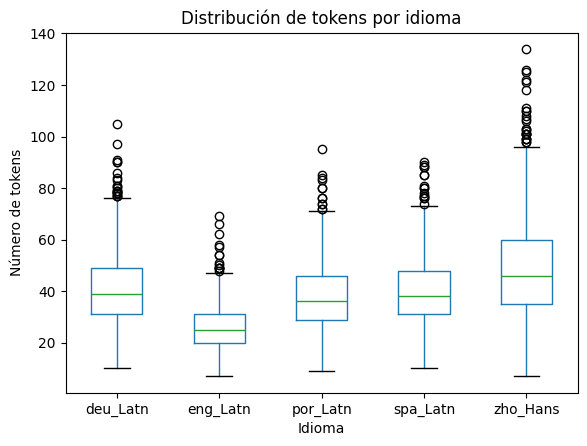

In [25]:
# ============================================================
# 12. BOXPLOT DE TOKENS POR IDIOMA
# ============================================================

plt.figure(figsize=(10, 6))
df.boxplot(column="Tokens", by="Idioma", grid=False)
plt.title("Distribución de tokens por idioma")
plt.suptitle("")
plt.xlabel("Idioma")
plt.ylabel("Número de tokens")
plt.show()

In [26]:
# ============================================================
# 14. EXPORTAR RESULTADOS
# ============================================================

df.to_csv("tokens_resultados_idtl.csv", index=False, encoding="utf-8-sig")
resumen_idioma.to_csv("resumen_tokens_por_idioma.csv", index=False, encoding="utf-8-sig")
resumen_idtl.to_csv("resumen_idtl_por_idioma.csv", index=False, encoding="utf-8-sig")
posthoc_df.to_csv("posthoc_wilcoxon_idiomas.csv", index=False, encoding="utf-8-sig")

In [27]:
# Descargar en Colab

from google.colab import files

files.download("tokens_resultados_idtl.csv")
files.download("resumen_tokens_por_idioma.csv")
files.download("resumen_idtl_por_idioma.csv")
files.download("posthoc_wilcoxon_idiomas.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# ============================================================
# 0. INSTALACIÓN
# ============================================================

!pip install tiktoken sentence-transformers pulp scipy -q

In [29]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import re
import tiktoken

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

In [30]:
# ============================================================
# 2. CARGA DE DATOS TOKENIZADOS
# ============================================================

df = pd.read_csv("/content/tokens_resultados_idtl.csv")

df.head()

,ID,Idioma,Nombre_Idioma,Texto,Split,Tokens,Caracteres,Palabras,Tokens_por_palabra,Tokens_por_caracter,Tokens_English,IDTL
0,0,eng_Latn,English,"On Monday, scientists from the Stanford Univer...",dev,49,264,43,1.139535,0.185606,49,1.0
1,1,eng_Latn,English,Lead researchers say this may bring early dete...,dev,41,229,36,1.138889,0.179039,41,1.0
2,2,eng_Latn,English,The JAS 39C Gripen crashed onto a runway at ar...,dev,36,137,24,1.500000,0.262774,36,1.0
3,3,eng_Latn,English,The pilot was identified as Squadron Leader Di...,dev,14,62,9,1.555556,0.225806,14,1.0
4,4,eng_Latn,English,Local media reports an airport fire vehicle ro...,dev,12,73,11,1.090909,0.164384,12,1.0


In [31]:
# ============================================================
# 3. TOKENIZADOR
# ============================================================

encoding = tiktoken.get_encoding("cl100k_base")

def contar_tokens(texto):
    return len(encoding.encode(str(texto)))

In [32]:
# ============================================================
# 4. GENERADOR SIMPLE DE CANDIDATOS OPTIMIZADOS
# ============================================================
# Nota:
# Esta primera versión NO usa API externa.
# Genera reformulaciones simples y reproducibles.
# Luego podemos reemplazar esto por una etapa LLM más potente.

def generar_candidatos(texto):
    texto = str(texto).strip()

    candidatos = []

    # Original
    candidatos.append(texto)

    # Limpieza de espacios
    candidatos.append(re.sub(r"\s+", " ", texto))

    # Quitar dobles signos y espacios antes de puntuación
    t1 = re.sub(r"\s+([,.!?;:])", r"\1", texto)
    candidatos.append(t1)

    # Eliminar expresiones redundantes comunes
    reemplazos = {
        "con el objetivo de": "para",
        "con la finalidad de": "para",
        "debido a que": "porque",
        "en el caso de": "para",
        "a través de": "mediante",
        "por medio de": "mediante",
        "en relación con": "sobre",
        "de manera significativa": "significativamente",
        "inteligencia artificial": "IA",
        "modelos de lenguaje de gran escala": "LLMs",
        "procesamiento de lenguaje natural": "PLN"
    }

    t2 = texto
    for largo, corto in reemplazos.items():
        t2 = re.sub(largo, corto, t2, flags=re.IGNORECASE)
    candidatos.append(t2)

    # Versión más compacta: eliminar algunas frases de relleno
    relleno = [
        "es importante señalar que",
        "cabe destacar que",
        "en este sentido",
        "por lo tanto",
        "sin embargo",
        "asimismo"
    ]

    t3 = texto
    for r in relleno:
        t3 = re.sub(r, "", t3, flags=re.IGNORECASE)
    t3 = re.sub(r"\s+", " ", t3).strip()
    candidatos.append(t3)

    # Quitar duplicados conservando orden
    candidatos_unicos = list(dict.fromkeys(candidatos))

    return candidatos_unicos

In [33]:
# ============================================================
# 5. MODELO DE SIMILITUD SEMÁNTICA
# ============================================================
# Modelo multilingüe ligero y robusto

modelo_emb = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [34]:
# ============================================================
# 6. OPTIMIZACIÓN TOKEN-LINGÜÍSTICA
# ============================================================

def optimizar_texto(texto, delta=0.90):
    candidatos = generar_candidatos(texto)

    # Embedding del original
    emb_original = modelo_emb.encode([texto])
    emb_candidatos = modelo_emb.encode(candidatos)

    resultados = []

    for candidato, emb in zip(candidatos, emb_candidatos):
        sim = cosine_similarity(emb_original, [emb])[0][0]
        tokens = contar_tokens(candidato)

        resultados.append({
            "Texto_Optimizado": candidato,
            "Tokens_Optimizados": tokens,
            "Similitud": sim
        })

    candidatos_df = pd.DataFrame(resultados)

    # Restricción semántica
    factibles = candidatos_df[candidatos_df["Similitud"] >= delta].copy()

    if len(factibles) == 0:
        mejor = candidatos_df.sort_values("Similitud", ascending=False).iloc[0]
    else:
        mejor = factibles.sort_values("Tokens_Optimizados", ascending=True).iloc[0]

    return mejor

In [35]:
# ============================================================
# 7. APLICAR OPTIMIZACIÓN
# ============================================================

delta = 0.90

resultados_opt = []

for idx, row in df.iterrows():
    texto_original = row["Texto"]
    tokens_original = row["Tokens"]

    mejor = optimizar_texto(texto_original, delta=delta)

    resultados_opt.append({
        "ID": row["ID"],
        "Idioma": row["Idioma"],
        "Nombre_Idioma": row["Nombre_Idioma"],
        "Texto_Original": texto_original,
        "Texto_Optimizado": mejor["Texto_Optimizado"],
        "Tokens_Original": tokens_original,
        "Tokens_Optimizados": mejor["Tokens_Optimizados"],
        "Similitud": mejor["Similitud"]
    })

df_opt = pd.DataFrame(resultados_opt)

df_opt.head()

,ID,Idioma,Nombre_Idioma,Texto_Original,Texto_Optimizado,Tokens_Original,Tokens_Optimizados,Similitud
0,0,eng_Latn,English,"On Monday, scientists from the Stanford Univer...","On Monday, scientists from the Stanford Univer...",49,49,1.0
1,1,eng_Latn,English,Lead researchers say this may bring early dete...,Lead researchers say this may bring early dete...,41,41,1.0
2,2,eng_Latn,English,The JAS 39C Gripen crashed onto a runway at ar...,The JAS 39C Gripen crashed onto a runway at ar...,36,36,1.0
3,3,eng_Latn,English,The pilot was identified as Squadron Leader Di...,The pilot was identified as Squadron Leader Di...,14,14,1.0
4,4,eng_Latn,English,Local media reports an airport fire vehicle ro...,Local media reports an airport fire vehicle ro...,12,12,1.0


In [36]:
# ============================================================
# 8. MÉTRICAS DE REDUCCIÓN
# ============================================================

df_opt["Reduccion_Tokens"] = df_opt["Tokens_Original"] - df_opt["Tokens_Optimizados"]

df_opt["Pct_Reduccion"] = (
    df_opt["Reduccion_Tokens"] / df_opt["Tokens_Original"]
) * 100

df_opt["Cumple_Restriccion"] = df_opt["Similitud"] >= delta

df_opt.head()

,ID,Idioma,Nombre_Idioma,Texto_Original,Texto_Optimizado,Tokens_Original,Tokens_Optimizados,Similitud,Reduccion_Tokens,Pct_Reduccion,Cumple_Restriccion
0,0,eng_Latn,English,"On Monday, scientists from the Stanford Univer...","On Monday, scientists from the Stanford Univer...",49,49,1.0,0,0.0,True
1,1,eng_Latn,English,Lead researchers say this may bring early dete...,Lead researchers say this may bring early dete...,41,41,1.0,0,0.0,True
2,2,eng_Latn,English,The JAS 39C Gripen crashed onto a runway at ar...,The JAS 39C Gripen crashed onto a runway at ar...,36,36,1.0,0,0.0,True
3,3,eng_Latn,English,The pilot was identified as Squadron Leader Di...,The pilot was identified as Squadron Leader Di...,14,14,1.0,0,0.0,True
4,4,eng_Latn,English,Local media reports an airport fire vehicle ro...,Local media reports an airport fire vehicle ro...,12,12,1.0,0,0.0,True


In [37]:
# ============================================================
# 9. RESUMEN POR IDIOMA
# ============================================================

resumen_opt = df_opt.groupby("Idioma").agg(
    Tokens_Original_Media=("Tokens_Original", "mean"),
    Tokens_Optimizados_Media=("Tokens_Optimizados", "mean"),
    Reduccion_Media=("Reduccion_Tokens", "mean"),
    Pct_Reduccion_Media=("Pct_Reduccion", "mean"),
    Similitud_Media=("Similitud", "mean"),
    Cumplimiento=("Cumple_Restriccion", "mean")
).reset_index()

resumen_opt

,Idioma,Tokens_Original_Media,Tokens_Optimizados_Media,Reduccion_Media,Pct_Reduccion_Media,Similitud_Media,Cumplimiento
0,deu_Latn,40.738215,40.735206,0.003009,0.006048,1.000000,1.0
1,eng_Latn,25.878636,25.876630,0.002006,0.005682,1.000000,1.0
2,por_Latn,38.291876,38.282849,0.009027,0.023345,1.000000,1.0
3,spa_Latn,40.006018,39.940822,0.065196,0.147017,0.999923,1.0
4,zho_Hans,48.900702,48.900702,0.000000,0.000000,1.000000,1.0


In [38]:
# ============================================================
# 10. PRUEBA ESTADÍSTICA H3
# ============================================================
# H0: No hay reducción significativa de tokens
# H1: Hay reducción significativa de tokens

stat, p_value = wilcoxon(
    df_opt["Tokens_Original"],
    df_opt["Tokens_Optimizados"]
)

print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Se rechaza H0: existe reducción significativa de tokens.")
else:
    print("No se rechaza H0: no hay evidencia suficiente de reducción.")

Wilcoxon statistic: 0.0
p-value: 1.0110747440265562e-08
Se rechaza H0: existe reducción significativa de tokens.


/tmp/ipykernel_3115/1820891817.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


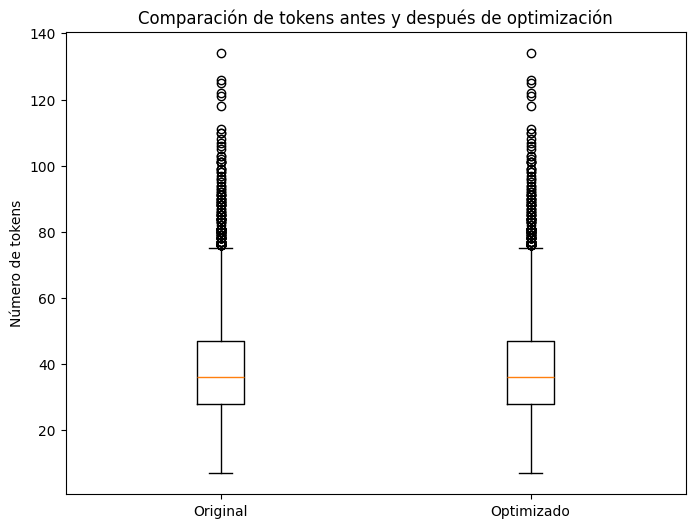

In [39]:
# ============================================================
# 11. GRÁFICO ORIGINAL VS OPTIMIZADO
# ============================================================

plt.figure(figsize=(8, 6))
plt.boxplot(
    [
        df_opt["Tokens_Original"],
        df_opt["Tokens_Optimizados"]
    ],
    labels=["Original", "Optimizado"]
)

plt.title("Comparación de tokens antes y después de optimización")
plt.ylabel("Número de tokens")
plt.show()

<Figure size 1000x600 with 0 Axes>

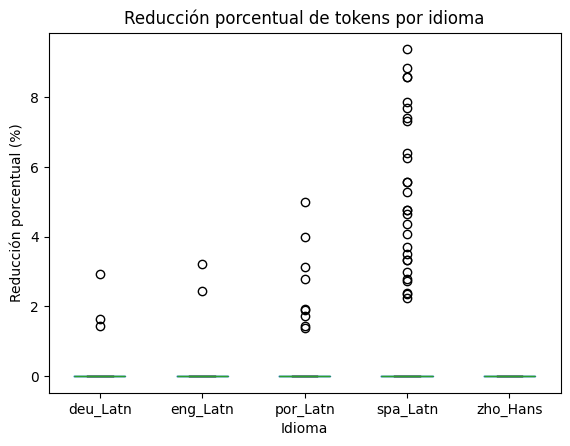

In [40]:
# ============================================================
# 12. REDUCCIÓN POR IDIOMA
# ============================================================

plt.figure(figsize=(10, 6))
df_opt.boxplot(column="Pct_Reduccion", by="Idioma", grid=False)

plt.title("Reducción porcentual de tokens por idioma")
plt.suptitle("")
plt.xlabel("Idioma")
plt.ylabel("Reducción porcentual (%)")
plt.show()

In [41]:
# ============================================================
# 13. EXPORTAR RESULTADOS
# ============================================================

df_opt.to_csv("resultados_optimizacion_token_linguistica.csv", index=False, encoding="utf-8-sig")
resumen_opt.to_csv("resumen_optimizacion_por_idioma.csv", index=False, encoding="utf-8-sig")

from google.colab import files

files.download("resultados_optimizacion_token_linguistica.csv")
files.download("resumen_optimizacion_por_idioma.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>